In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,OrdinalEncoder,FunctionTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
df = pd.read_csv("/content/drive/MyDrive/LABS/00_DATASETS/reclamos_salud.csv",encoding='latin-1')

In [27]:
df.head()

,Edad_Paciente,especialidad medica,gravedad_diagnostico,dias_hospitalizacion,costo_estancia,numero_procedimientos,Monto_Asegurado_USD,condiciones_preexistentes,historial_reclamos_Previos,monto_total_reclamado,estado_reclamo
0,75,Cardiologia,Leve,19,6644.40,8.0,50000.0,Si,5,13759.94,Fraude
1,64,Cardiologia,Critica,8,2801.13,5.0,15000.0,No,2,4176.99,Legitimo
2,46,Oncologia,Leve,11,3850.30,4.0,50000.0,No,3,1238.87,Legitimo
3,41,Oncologia,Moderada,1,346.64,2.0,10000.0,Si,0,951.18,Legitimo
4,79,Cardiologia,Moderada,1,351.85,4.0,10000.0,No,3,6339.86,Legitimo


In [28]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 900 entries, 0 to 909
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Edad_Paciente               900 non-null    int64  
 1   especialidad medica         864 non-null    object 
 2   gravedad_diagnostico        900 non-null    object 
 3   dias_hospitalizacion        900 non-null    int64  
 4   costo_estancia              900 non-null    float64
 5   numero_procedimientos       855 non-null    float64
 6   Monto_Asegurado_USD         900 non-null    float64
 7   condiciones_preexistentes   855 non-null    object 
 8   historial_reclamos_Previos  900 non-null    int64  
 9   monto_total_reclamado       900 non-null    float64
 10  estado_reclamo              900 non-null    object 
dtypes: float64(4), int64(3), object(4)
memory usage: 84.4+ KB


,0
Edad_Paciente,0
especialidad medica,36
gravedad_diagnostico,0
dias_hospitalizacion,0
costo_estancia,0
numero_procedimientos,45
Monto_Asegurado_USD,0
condiciones_preexistentes,45
historial_reclamos_Previos,0
monto_total_reclamado,0


In [53]:
df.columns= df.columns.str.strip()
df.colums = df.columns.str.lower()
df.colums = df.columns.str.replace(" ","_")
df.columns

Index(['Edad_Paciente', 'especialidad medica', 'gravedad_diagnostico',
       'dias_hospitalizacion', 'costo_estancia', 'numero_procedimientos',
       'Monto_Asegurado_USD', 'condiciones_preexistentes',
       'historial_reclamos_Previos', 'monto_total_reclamado',
       'estado_reclamo'],
      dtype='object')

In [95]:
df["Monto_Asegurado_USD"] = df["Monto_Asegurado_USD"].astype(float)

In [49]:
df["especialidad medica"] = df["especialidad medica"].str.strip()
df["gravedad_diagnostico"] = df["gravedad_diagnostico"].str.strip()
df["condiciones_preexistentes"] = df["condiciones_preexistentes"].str.strip()
df["estado_reclamo"] = df["estado_reclamo"].str.strip()

In [57]:
df["especialidad medica"] = df["especialidad medica"].fillna(df["especialidad medica"].mode()[0])
df["condiciones_preexistentes"] = df["condiciones_preexistentes"].fillna(df["condiciones_preexistentes"].mode()[0])
df["numero_procedimientos"] = df["numero_procedimientos"].fillna(df["numero_procedimientos"].median())
df.isnull().sum()

,0
Edad_Paciente,0
especialidad medica,0
gravedad_diagnostico,0
dias_hospitalizacion,0
costo_estancia,0
numero_procedimientos,0
Monto_Asegurado_USD,0
condiciones_preexistentes,0
historial_reclamos_Previos,0
monto_total_reclamado,0


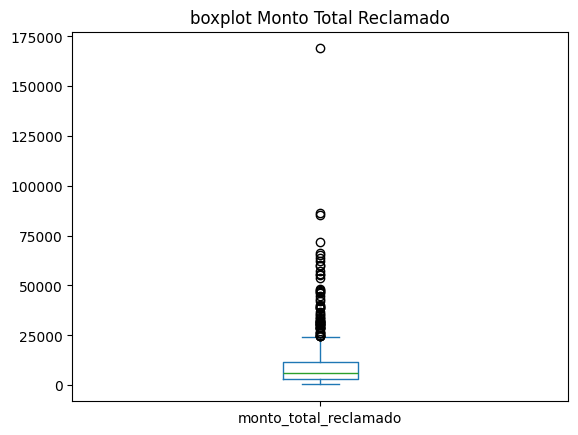

In [58]:
df["monto_total_reclamado"].plot(kind="box")
plt.title("boxplot Monto Total Reclamado")
plt.show()

In [60]:
q1 = df["monto_total_reclamado"].quantile(0.25)
q3 = df["monto_total_reclamado"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr


df["monto_total_reclamado"] = np.where(df["monto_total_reclamado"] > limite_superior, limite_superior, df["monto_total_reclamado"])
df["monto_total_reclamado"] = np.where(df["monto_total_reclamado"] < limite_inferior, limite_inferior, df["monto_total_reclamado"])


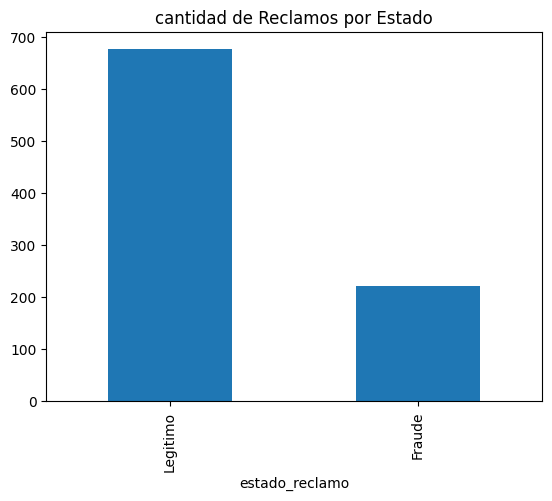

In [61]:
df["estado_reclamo"].value_counts().plot(kind="bar")
plt.title("cantidad de Reclamos por Estado")
plt.show()

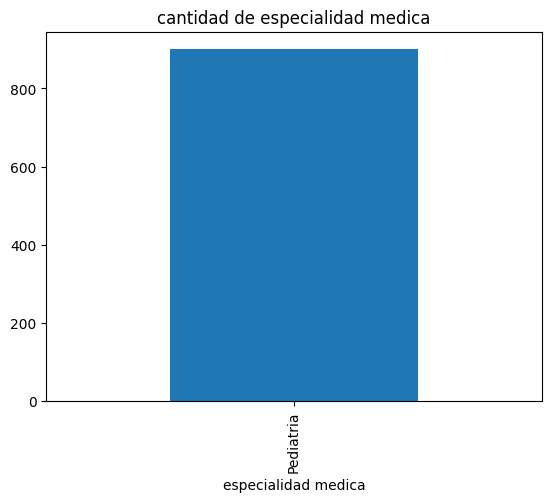

In [62]:
df["especialidad medica"].value_counts().plot(kind="bar")
plt.title("cantidad de especialidad medica")
plt.show()

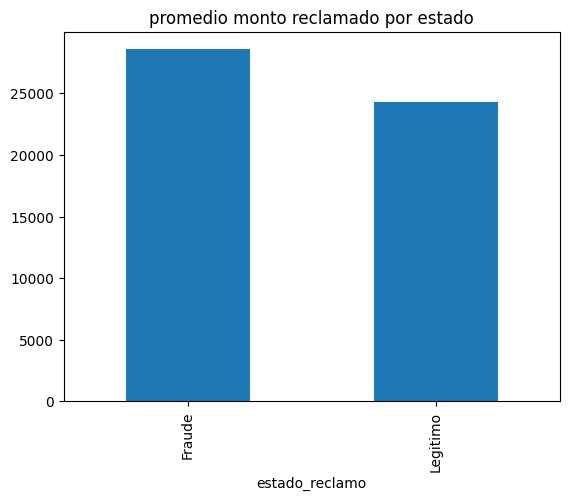

In [63]:
df.groupby("estado_reclamo")["monto_total_reclamado"].mean().plot(kind="bar")
plt.title("promedio monto reclamado por estado")
plt.show()

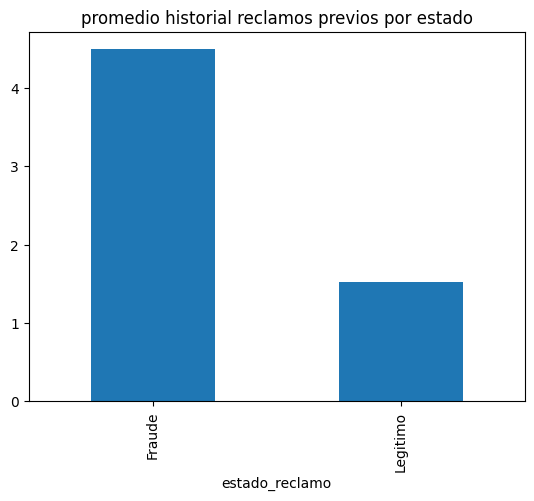

In [64]:
df.groupby("estado_reclamo")["historial_reclamos_Previos"].mean().plot(kind="bar")
plt.title("promedio historial reclamos previos por estado")
plt.show()

In [65]:
df_corr = df.copy()
df_corr["estado_reclamo_num"] = df_corr["estado_reclamo"].replace({"legitimo":0,"fraude":1})

corr= df_corr.select_dtypes(include=["int64","float64"]).corr()
corr

,Edad_Paciente,dias_hospitalizacion,costo_estancia,numero_procedimientos,Monto_Asegurado_USD,historial_reclamos_Previos,monto_total_reclamado
Edad_Paciente,1.000000,-0.000942,-0.000895,NaN,-0.052669,-0.056245,-0.018596
dias_hospitalizacion,-0.000942,1.000000,0.999997,NaN,-0.004686,0.458431,0.169463
costo_estancia,-0.000895,0.999997,1.000000,NaN,-0.004708,0.458450,0.169339
numero_procedimientos,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monto_Asegurado_USD,-0.052669,-0.004686,-0.004708,NaN,1.000000,0.031267,-0.000157
historial_reclamos_Previos,-0.056245,0.458431,0.458450,NaN,0.031267,1.000000,0.148820
monto_total_reclamado,-0.018596,0.169463,0.169339,NaN,-0.000157,0.148820,1.000000


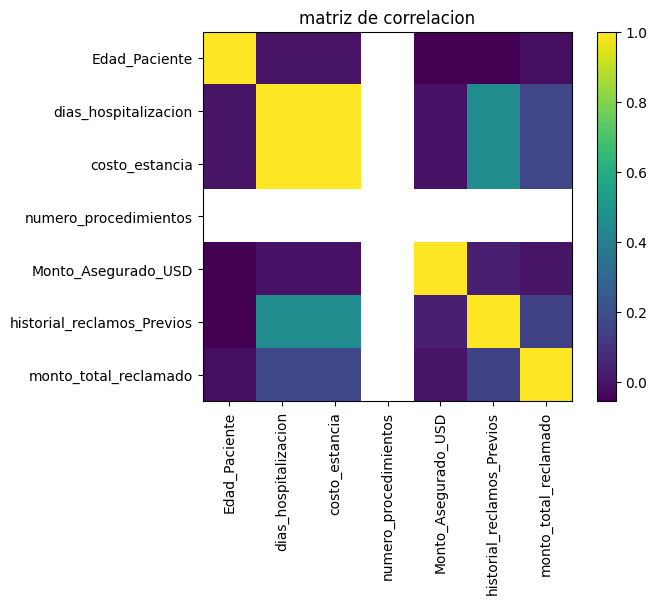

In [72]:
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("matriz de correlacion")
plt.show()

In [74]:
df["diferencia_monto"] = df["Monto_Asegurado_USD"] - df["monto_total_reclamado"]
df["costo_por_dia"] = df["costo_estancia"] / df["dias_hospitalizacion"]
df["costo_por_dia"] = df["costo_por_dia"].replace([np.inf, -np.inf],0)

df.head()

,Edad_Paciente,especialidad medica,gravedad_diagnostico,dias_hospitalizacion,costo_estancia,numero_procedimientos,Monto_Asegurado_USD,condiciones_preexistentes,historial_reclamos_Previos,monto_total_reclamado,estado_reclamo,diferencia_monto,costo_por_dia
0,75,Pediatria,Leve,19,6644.40,4.0,50000.0,No,5,24129.0325,Fraude,25870.9675,349.705263
1,64,Pediatria,Critica,8,2801.13,4.0,15000.0,No,2,24129.0325,Legitimo,-9129.0325,350.141250
2,46,Pediatria,Leve,11,3850.30,4.0,50000.0,No,3,24129.0325,Legitimo,25870.9675,350.027273
3,41,Pediatria,Moderada,1,346.64,4.0,10000.0,No,0,24129.0325,Legitimo,-14129.0325,346.640000
4,79,Pediatria,Moderada,1,351.85,4.0,10000.0,No,3,24129.0325,Legitimo,-14129.0325,351.850000


In [75]:
x=df.drop("estado_reclamo",axis=1)
y=df["estado_reclamo"]

In [76]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [144]:
categoricas_nominales=["especialidad medica","condiciones_preexistentes"]
categoricas_ordinales=["gravedad_diagnostico"]
numericas_standar=["edad_paciente","dias_hospitalizacion","costo_estancia","numero_procedimientos","Monto_Asegurado_USD","historial_reclamos_previos","diferencia_monto","costo_por_dia"]

numerica_log=["monto_total_reclamado"]

In [145]:
pipe_nominal= Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(categories=[["leve","moderado","critico"]]))])


In [146]:
pipe_ordinal= Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),("ordinal", OrdinalEncoder(categories=[["leve","moderado","critico"]]))])

In [147]:
pipe_numerica= Pipeline([("imputar", SimpleImputer(strategy="median")),("escalar", StandardScaler())])

In [148]:
pipe_log= Pipeline([("imputar", SimpleImputer(strategy="median")),("log", FunctionTransformer(np.log1p)),("escalar", StandardScaler())])


In [149]:
preprocesamiento=ColumnTransformer([("nominales",pipe_nominal,categoricas_nominales),("numericas",pipe_numerica,numericas_standar),("ordinales",pipe_ordinal,categoricas_ordinales),("log",pipe_log,numerica_log)])


In [153]:
x_train_prep=preprocesamiento.fit_transform(x_train)
x_test_prep=preprocesamiento.transform(x_test)

x_train_prep

ValueError: A given column is not a column of the dataframe